# 07. Nonlinear functional robustness

## Objective

This controlled single-seed experiment asks whether the frozen Simple Event Volatility Model workflow remains informative when the data-generating functions for $\alpha_i$, $\nu_i$, and $\rho_i$ depart from their benchmark forms. It distinguishes a **functional-form change** from a scalar parameter change: the benchmark scalar configuration, event calendar, response horizon, estimator, and forecasting workflow remain fixed.

The powered volatility state is

$$
X_i = \sigma_i^n.
$$

This notebook is restricted to $n=1$, so $X_i=\sigma_i$. The inherited timing is

$$
E_i \longrightarrow \omega_{i+1} \longrightarrow X_{i+1}.
$$

An event at transition $i$ affects $X_{i+1}$; event ages $0,\ldots,h$ therefore map to TDMI state lags $+1,\ldots,h+1$.

Notebook 06 supplies the frozen methodology. No estimator is redesigned here, no hidden DGP quantity enters fitting, and no Monte Carlo replication is performed.

## 1. Load the frozen workflow

Notebook 07 directly loads Notebook 06 with its self-tests disabled. The available interfaces are inspected before use; workflow helpers are not redefined here.

In [12]:
RUN_HELPER_SELF_TESTS = False
%run "./06_experiment_workflow_helpers.ipynb"

import inspect
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

required_workflow_functions = {
    'run_full_pipeline': run_full_pipeline,
    'summarise_case': summarise_case,
    'make_case_config': make_case_config,
    'make_shock_bank': make_shock_bank,
    'derive_timing': derive_timing,
}
assert all(callable(function) for function in required_workflow_functions.values())
workflow_interface = inspect.signature(run_full_pipeline)
print('run_full_pipeline interface:', workflow_interface)
print('Notebook 06 helpers loaded; helper self-tests were intentionally skipped.')

Helper self-tests skipped for downstream use.
run_full_pipeline interface: (case_config, shock_bank=None, seed=None, baseline_feature_builder=None, include_causality=True, include_intervals=True, include_truth=False, functions=None)
Notebook 06 helpers loaded; helper self-tests were intentionally skipped.


## 2. Benchmark configuration and common shocks

The benchmark configuration and its validated shock generator are inherited from Notebook 06. Notebook 00 supplies time in **years** (the grid is transition index divided by trading steps per year), so $\sin(2\pi t)$ is one full cycle per model year. The same standard-normal epsilon and eta arrays are supplied to every case.

In [13]:
benchmark_case = make_case_config(reference_config, label='benchmark')
benchmark_timing = derive_timing(benchmark_case)
common_shock_bank = make_shock_bank(benchmark_case)
common_seed = benchmark_case['simulation']['seed']

assert benchmark_case['model']['n'] == 1
assert set(common_shock_bank) == {'z_epsilon', 'z_eta'}
assert len(common_shock_bank['z_epsilon']) == len(common_shock_bank['z_eta'])
print(f'Common shock seed: {common_seed}; transitions: {len(common_shock_bank["z_epsilon"])}.')
print('Time argument is annual model time; time-varying functions use sin(2*pi*t).')

Common shock seed: 20260721; transitions: 504.
Time argument is annual model time; time-varying functions use sin(2*pi*t).


## 3. Alternative data-generating functionals

Every function uses Notebook 06's native positional interface `function(t, S, sigma, returns, params)` and reads constants from `params`. Define the normalised volatility-state deviation as

$$
z_i = \frac{\sigma_i-\theta}{\theta}.
$$

### Bounded nonlinear alpha

$$
\alpha_i^{(\mathrm{bounded})} = -\frac{\kappa\theta}{3}\tanh(3z_i).
$$

Near equilibrium this agrees locally with linear mean reversion. Far from equilibrium its restoring force saturates, so extreme states receive weaker correction.

### Superlinear alpha

$$
\alpha_i^{(\mathrm{superlinear})} = \kappa(\theta-\sigma_i)(1+4z_i^2).
$$

This remains close to the benchmark near $\theta$, but strengthens mean reversion as the volatility state moves farther away.

### State-dependent nu

$$
\nu_i^{(\mathrm{state})} = \nu_0[1+0.5\tanh(3z_i)].
$$

It remains strictly positive and varies smoothly between one half and one and a half times $\nu_0$. It makes transition uncertainty depend on the current volatility state.

### Time-varying nu

$$
\nu_i^{(\mathrm{time})} = \nu_0[1+0.4\sin(2\pi t_i)].
$$

Notebook 00 passes $t_i$ in years, so this produces one complete cycle per model year. It changes background innovation scale without using the current state.

### State-dependent rho

$$
\rho_i^{(\mathrm{state})} = \tanh\!\left[\operatorname{arctanh}(\rho_0)-1.5z_i\right].
$$

The $\tanh$ map keeps correlation strictly inside $(-1,1)$. Above $\theta$, correlation becomes more negative, changing how much of the volatility shock is revealed by the observed price shock.

### Time-varying rho

$$
\rho_i^{(\mathrm{time})} = \tanh\!\left[\operatorname{arctanh}(\rho_0)+0.6\sin(2\pi t_i)\right].
$$

This also completes one cycle per model year while preserving valid correlation bounds. The event-weight function and all scalar benchmark parameters remain unchanged.

In [14]:
def _normalised_state_deviation(sigma, params):
    theta = float(params['theta'])
    return (float(sigma) - theta) / max(theta, 1e-12)


def alpha_bounded_nonlinear(t, S, sigma, returns, params):
    z = _normalised_state_deviation(sigma, params)
    return float(-(params['kappa'] * params['theta'] / 3.0) * np.tanh(3.0 * z))


def alpha_superlinear(t, S, sigma, returns, params):
    z = _normalised_state_deviation(sigma, params)
    return float(params['kappa'] * (params['theta'] - sigma) * (1.0 + 4.0 * z ** 2))


def nu_state_dependent(t, S, sigma, returns, params):
    z = _normalised_state_deviation(sigma, params)
    return float(params['nu_0'] * (1.0 + 0.5 * np.tanh(3.0 * z)))


def nu_time_varying(t, S, sigma, returns, params):
    return float(params['nu_0'] * (1.0 + 0.4 * np.sin(2.0 * np.pi * t)))


def _safe_atanh_rho(params):
    rho_0 = float(params['rho_0'])
    return np.arctanh(np.clip(rho_0, -1.0 + 1e-12, 1.0 - 1e-12))


def rho_state_dependent(t, S, sigma, returns, params):
    z = _normalised_state_deviation(sigma, params)
    return float(np.tanh(_safe_atanh_rho(params) - 1.5 * z))


def rho_time_varying(t, S, sigma, returns, params):
    return float(np.tanh(_safe_atanh_rho(params) + 0.6 * np.sin(2.0 * np.pi * t)))

alternative_functions = {
    'alpha_bounded_nonlinear': alpha_bounded_nonlinear,
    'alpha_superlinear': alpha_superlinear,
    'nu_state_dependent': nu_state_dependent,
    'nu_time_varying': nu_time_varying,
    'rho_state_dependent': rho_state_dependent,
    'rho_time_varying': rho_time_varying,
}
assert all(callable(function) for function in alternative_functions.values())

## 4. Functional diagnostics before simulation

The following diagnostic plots evaluate the functions directly. They verify finite outputs, positive nu, valid rho, local benchmark agreement at equilibrium, and meaningful departures away from equilibrium or across time.

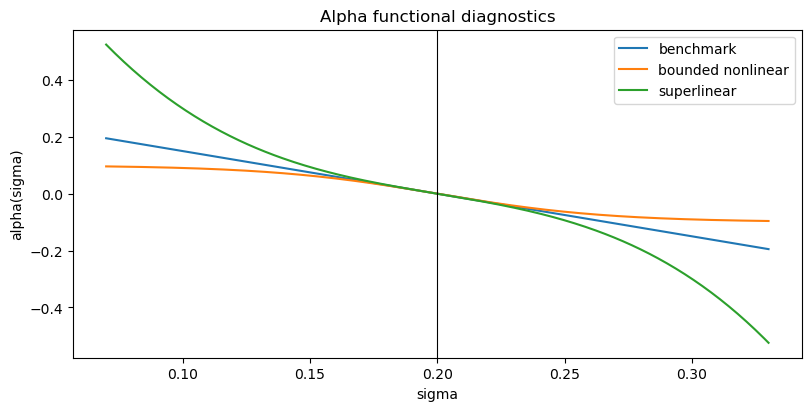

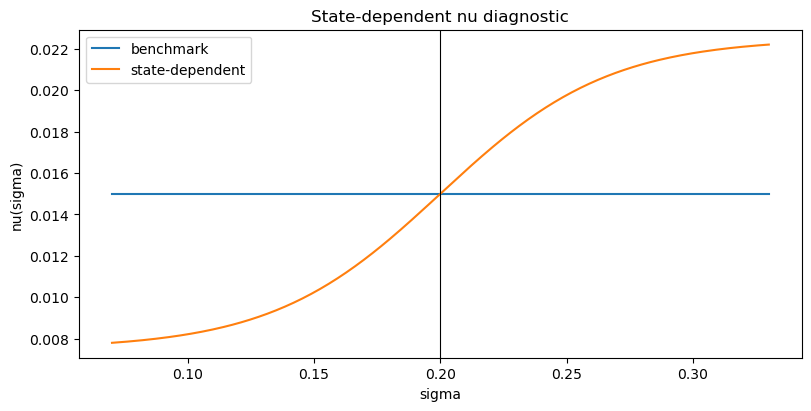

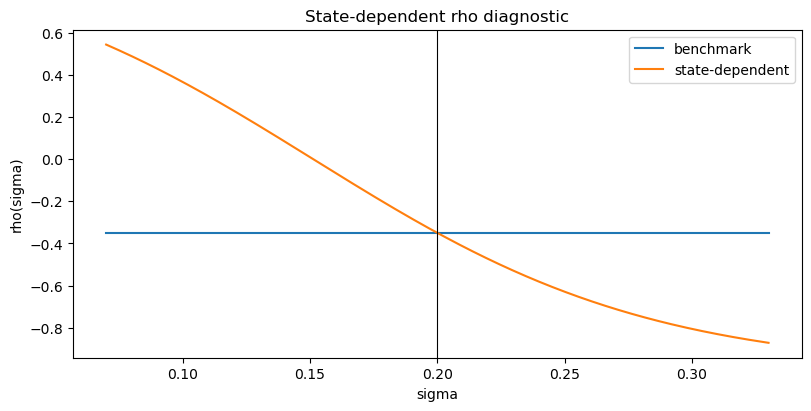

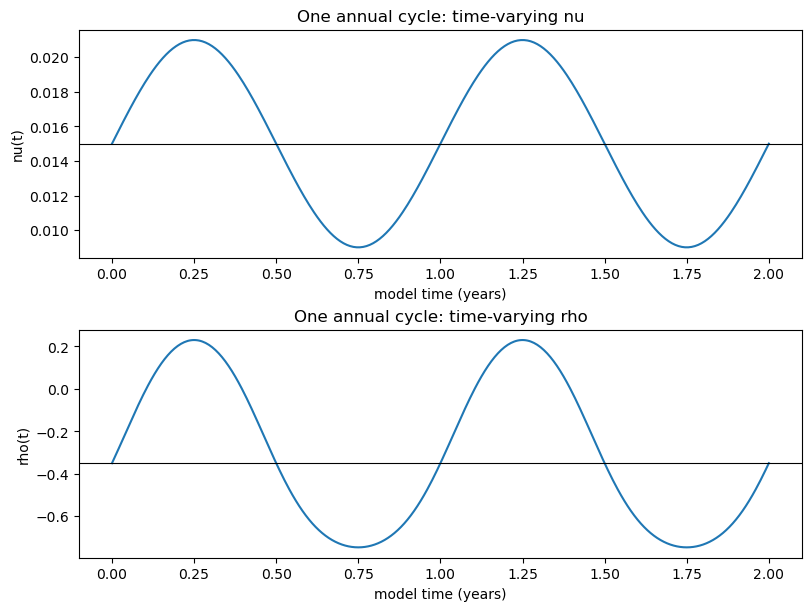

In [15]:
model_params = benchmark_case['model']
theta = float(model_params['theta'])
state_grid = np.linspace(0.35 * theta, 1.65 * theta, 301)
time_grid_diagnostic = np.linspace(0.0, benchmark_case['simulation']['years'], 401)
empty_returns = np.array([], dtype=float)

alpha_benchmark_values = np.array([alpha_fn(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
alpha_bounded_values = np.array([alpha_bounded_nonlinear(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
alpha_superlinear_values = np.array([alpha_superlinear(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
nu_benchmark_values = np.array([nu_fn(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
nu_state_values = np.array([nu_state_dependent(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
rho_benchmark_values = np.array([rho_fn(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
rho_state_values = np.array([rho_state_dependent(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
nu_time_values = np.array([nu_time_varying(t, 100.0, theta, empty_returns, model_params) for t in time_grid_diagnostic])
rho_time_values = np.array([rho_time_varying(t, 100.0, theta, empty_returns, model_params) for t in time_grid_diagnostic])

all_function_values = [alpha_benchmark_values, alpha_bounded_values, alpha_superlinear_values, nu_benchmark_values, nu_state_values, rho_benchmark_values, rho_state_values, nu_time_values, rho_time_values]
assert all(np.isfinite(values).all() for values in all_function_values)
assert (nu_state_values > 0).all() and (nu_time_values > 0).all()
assert ((rho_state_values > -1) & (rho_state_values < 1)).all()
assert ((rho_time_values > -1) & (rho_time_values < 1)).all()
assert np.isclose(alpha_bounded_nonlinear(0.0, 100.0, theta, empty_returns, model_params), 0.0)
assert np.isclose(alpha_superlinear(0.0, 100.0, theta, empty_returns, model_params), 0.0)
assert np.isclose(nu_state_dependent(0.0, 100.0, theta, empty_returns, model_params), model_params['nu_0'])
assert np.isclose(rho_state_dependent(0.0, 100.0, theta, empty_returns, model_params), model_params['rho_0'])
assert np.isclose(nu_time_varying(0.0, 100.0, theta, empty_returns, model_params), model_params['nu_0'])
assert np.isclose(rho_time_varying(0.0, 100.0, theta, empty_returns, model_params), model_params['rho_0'])
assert np.max(np.abs(alpha_bounded_values - alpha_benchmark_values)) > 1e-6
assert np.max(np.abs(alpha_superlinear_values - alpha_benchmark_values)) > 1e-6
assert np.max(np.abs(nu_state_values - nu_benchmark_values)) > 1e-6
assert np.max(np.abs(rho_state_values - rho_benchmark_values)) > 1e-6
assert np.ptp(nu_time_values) > 1e-6 and np.ptp(rho_time_values) > 1e-6

fig, axis = plt.subplots(figsize=(8, 4), constrained_layout=True)
axis.plot(state_grid, alpha_benchmark_values, label='benchmark')
axis.plot(state_grid, alpha_bounded_values, label='bounded nonlinear')
axis.plot(state_grid, alpha_superlinear_values, label='superlinear')
axis.axvline(theta, color='black', linewidth=0.8)
axis.set(xlabel='sigma', ylabel='alpha(sigma)', title='Alpha functional diagnostics')
axis.legend(); plt.show()

fig, axis = plt.subplots(figsize=(8, 4), constrained_layout=True)
axis.plot(state_grid, nu_benchmark_values, label='benchmark')
axis.plot(state_grid, nu_state_values, label='state-dependent')
axis.axvline(theta, color='black', linewidth=0.8)
axis.set(xlabel='sigma', ylabel='nu(sigma)', title='State-dependent nu diagnostic')
axis.legend(); plt.show()

fig, axis = plt.subplots(figsize=(8, 4), constrained_layout=True)
axis.plot(state_grid, rho_benchmark_values, label='benchmark')
axis.plot(state_grid, rho_state_values, label='state-dependent')
axis.axvline(theta, color='black', linewidth=0.8)
axis.set(xlabel='sigma', ylabel='rho(sigma)', title='State-dependent rho diagnostic')
axis.legend(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), constrained_layout=True)
axes[0].plot(time_grid_diagnostic, nu_time_values); axes[0].axhline(model_params['nu_0'], color='black', linewidth=0.8)
axes[0].set(xlabel='model time (years)', ylabel='nu(t)', title='One annual cycle: time-varying nu')
axes[1].plot(time_grid_diagnostic, rho_time_values); axes[1].axhline(model_params['rho_0'], color='black', linewidth=0.8)
axes[1].set(xlabel='model time (years)', ylabel='rho(t)', title='One annual cycle: time-varying rho')
plt.show()

## 5. Nine-case registry

Only the function(s) that differ are passed as partial overrides. Scalar parameters, event schedule, response horizon, state power, estimator, and interval construction remain inherited from the benchmark.

In [16]:
case_registry = [
    {'case_name': 'benchmark', 'description': 'frozen benchmark functions', 'functions': {}},
    {'case_name': 'alpha_bounded', 'description': 'bounded nonlinear alpha', 'functions': {'alpha_fn': alpha_bounded_nonlinear}},
    {'case_name': 'alpha_superlinear', 'description': 'superlinear alpha', 'functions': {'alpha_fn': alpha_superlinear}},
    {'case_name': 'nu_state_dependent', 'description': 'state-dependent nu', 'functions': {'nu_fn': nu_state_dependent}},
    {'case_name': 'nu_time_varying', 'description': 'time-varying nu', 'functions': {'nu_fn': nu_time_varying}},
    {'case_name': 'rho_state_dependent', 'description': 'state-dependent rho', 'functions': {'rho_fn': rho_state_dependent}},
    {'case_name': 'rho_time_varying', 'description': 'time-varying rho', 'functions': {'rho_fn': rho_time_varying}},
    {'case_name': 'mixed_state_dependent', 'description': 'bounded alpha, state nu, state rho', 'functions': {'alpha_fn': alpha_bounded_nonlinear, 'nu_fn': nu_state_dependent, 'rho_fn': rho_state_dependent}},
    {'case_name': 'mixed_time_and_state', 'description': 'superlinear alpha, time nu, time rho', 'functions': {'alpha_fn': alpha_superlinear, 'nu_fn': nu_time_varying, 'rho_fn': rho_time_varying}},
]
assert [case['case_name'] for case in case_registry] == ['benchmark','alpha_bounded','alpha_superlinear','nu_state_dependent','nu_time_varying','rho_state_dependent','rho_time_varying','mixed_state_dependent','mixed_time_and_state']
assert all(set(case['functions']).issubset({'alpha_fn','nu_fn','rho_fn'}) for case in case_registry)
case_registry_table = pd.DataFrame([{key: value for key, value in case.items() if key != 'functions'} for case in case_registry])
display(case_registry_table)

,case_name,description
0,benchmark,frozen benchmark functions
1,alpha_bounded,bounded nonlinear alpha
2,alpha_superlinear,superlinear alpha
3,nu_state_dependent,state-dependent nu
4,nu_time_varying,time-varying nu
5,rho_state_dependent,state-dependent rho
6,rho_time_varying,time-varying rho
7,mixed_state_dependent,"bounded alpha, state nu, state rho"
8,mixed_time_and_state,"superlinear alpha, time nu, time rho"


## 6. Benchmark reproduction

The benchmark is run first without overrides. It is reproduced with the same shock bank before alternatives are considered; this confirms that the frozen workflow remains callable and deterministic in this notebook.

In [17]:
benchmark_result = run_full_pipeline(
    benchmark_case,
    shock_bank=common_shock_bank,
    include_causality=True,
    include_intervals=True,
    include_truth=False,
    functions=None,
)
benchmark_repeat = run_full_pipeline(
    benchmark_case,
    shock_bank=common_shock_bank,
    include_causality=True,
    include_intervals=True,
    include_truth=False,
    functions=None,
)
benchmark_summary = summarise_case(benchmark_result)
repeat_summary = summarise_case(benchmark_repeat)

assert benchmark_result['truth'] is None
assert benchmark_result['config']['model']['n'] == 1
assert benchmark_result['simulation']['states'][['S','sigma','x']].gt(0).all().all()
assert benchmark_result['simulation']['transitions'][['F','x_next','sigma_next','omega_next']].gt(0).all().all()
assert benchmark_summary['training_count'] == repeat_summary['training_count']
assert benchmark_summary['testing_count'] == repeat_summary['testing_count']
assert np.isclose(benchmark_summary['A_hat'], repeat_summary['A_hat'])
assert np.isclose(benchmark_summary['lambda_hat'], repeat_summary['lambda_hat'])
assert np.isclose(benchmark_summary['active_sigma_parametric_MAE'], repeat_summary['active_sigma_parametric_MAE'])
print('Benchmark reproduction passed with the frozen common-shock workflow.')

Benchmark reproduction passed with the frozen common-shock workflow.


## 7. Run the nine cases with paired shocks

Every case uses the same benchmark configuration and shock bank. Failures are deliberately not swallowed: an invalid state or failed assertion stops the notebook rather than being silently converted into a result row.

In [18]:
case_results = {'benchmark': benchmark_result}
for case in case_registry[1:]:
    case_config = make_case_config(reference_config, label=case['case_name'])
    case_results[case['case_name']] = run_full_pipeline(
        case_config,
        shock_bank=common_shock_bank,
        include_causality=True,
        include_intervals=True,
        include_truth=False,
        functions=case['functions'],
    )

assert set(case_results) == set(case_registry_table['case_name'])
assert all(result['truth'] is None for result in case_results.values())
assert all(result['config']['model']['n'] == 1 for result in case_results.values())
assert all(np.array_equal(result['simulation']['transitions']['epsilon'], benchmark_result['simulation']['transitions']['epsilon']) for result in case_results.values())
assert all(np.array_equal(result['simulation']['transitions']['eta'], benchmark_result['simulation']['transitions']['eta']) for result in case_results.values())
assert all(result['simulation']['states'][['S','sigma','x']].gt(0).all().all() for result in case_results.values())
print(f'Completed {len(case_results)} paired common-shock cases.')

Completed 9 paired common-shock cases.


## 8. Causality and information diagnostics across functionals

The frozen Notebook 06 methodology is applied to every functional case, producing three distinct diagnostics:

1. **Historical Granger causality**: a lagged linear predictive test using historical target and event lags.
2. **Conditional predictive structure**: the separate conditional OLS event-history test, which is not labelled as Granger causality.
3. **Time-delayed mutual information (TDMI)**: a direct contingency-table dependence measure.

Unrestricted TDMI global peaks can be affected by state persistence and periodic event-calendar aliases. The direct-response window is the main structurally relevant comparison.

Historical Granger causality


,case_name,target,direction,lag_order,F_statistic,p_value,partial_R_squared,sample_size,significant_5pct
0,benchmark,powered-state level,event history -> target,13,3.9495,4.061e-06,0.102005,479,True
1,benchmark,powered-state change,event history -> target,13,3.8717,5.837e-06,0.100397,478,True
2,alpha_bounded,powered-state level,event history -> target,13,4.0049,3.138e-06,0.103289,479,True
3,alpha_bounded,powered-state change,event history -> target,13,3.8997,5.127e-06,0.101050,478,True
4,alpha_superlinear,powered-state level,event history -> target,13,3.8875,5.417e-06,0.100564,479,True
5,alpha_superlinear,powered-state change,event history -> target,13,3.8401,6.758e-06,0.099658,478,True
6,nu_state_dependent,powered-state level,event history -> target,13,3.0448,2.490e-04,0.080521,479,True
7,nu_state_dependent,powered-state change,event history -> target,13,2.9774,3.355e-04,0.079040,478,True
8,nu_time_varying,powered-state level,event history -> target,13,3.3809,5.530e-05,0.088620,479,True
9,nu_time_varying,powered-state change,event history -> target,13,3.2896,8.359e-05,0.086610,478,True


Conditional predictive structure


,case_name,target,direction,F_statistic,p_value,partial_r_squared,nobs
0,benchmark,state_next,event history -> target,3.2508,1.186e-04,0.113828,345
1,benchmark,delta_state_next,event history -> target,3.2508,1.186e-04,0.113828,345
2,alpha_bounded,state_next,event history -> target,3.2695,1.093e-04,0.114409,345
3,alpha_bounded,delta_state_next,event history -> target,3.2695,1.093e-04,0.114409,345
4,alpha_superlinear,state_next,event history -> target,3.2266,1.317e-04,0.113078,345
5,alpha_superlinear,delta_state_next,event history -> target,3.2266,1.317e-04,0.113078,345
6,nu_state_dependent,state_next,event history -> target,2.3496,5.215e-03,0.084954,345
7,nu_state_dependent,delta_state_next,event history -> target,2.3496,5.215e-03,0.084954,345
8,nu_time_varying,state_next,event history -> target,2.5316,2.499e-03,0.090935,345
9,nu_time_varying,delta_state_next,event history -> target,2.5316,2.499e-03,0.090935,345


Time-delayed mutual information summaries


,case_name,target,direct_response_peak,direct_response_lag,first_cycle_peak,first_cycle_lag,global_peak,global_peak_lag
0,benchmark,level,0.010993,8,0.010993,8,0.010993,8
1,benchmark,change,0.024192,1,0.024192,1,0.024620,-20
2,alpha_bounded,level,0.009868,8,0.009868,8,0.010316,-15
3,alpha_bounded,change,0.023764,1,0.023764,1,0.023764,1
4,alpha_superlinear,level,0.011323,6,0.011323,6,0.011522,-15
5,alpha_superlinear,change,0.023810,1,0.023810,1,0.023810,1
6,nu_state_dependent,level,0.009503,6,0.009503,6,0.009873,-15
7,nu_state_dependent,change,0.023837,9,0.023837,9,0.023837,9
8,nu_time_varying,level,0.013080,9,0.013080,9,0.013157,-12
9,nu_time_varying,change,0.028019,1,0.028019,1,0.028019,1


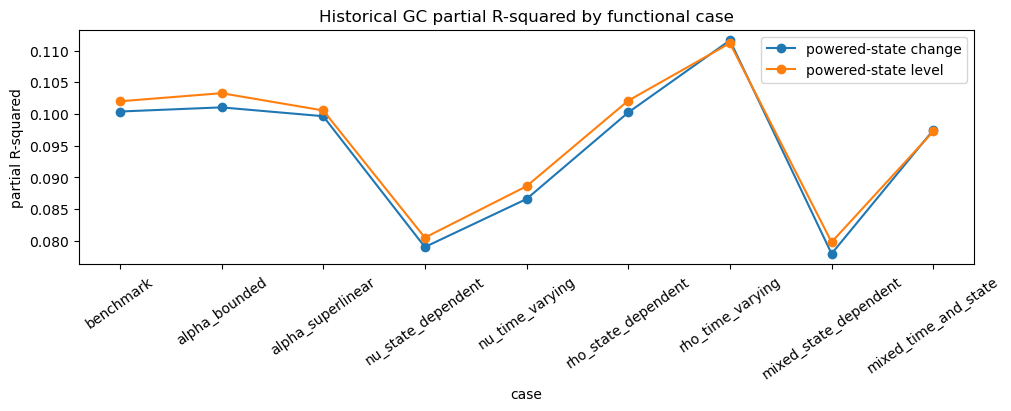

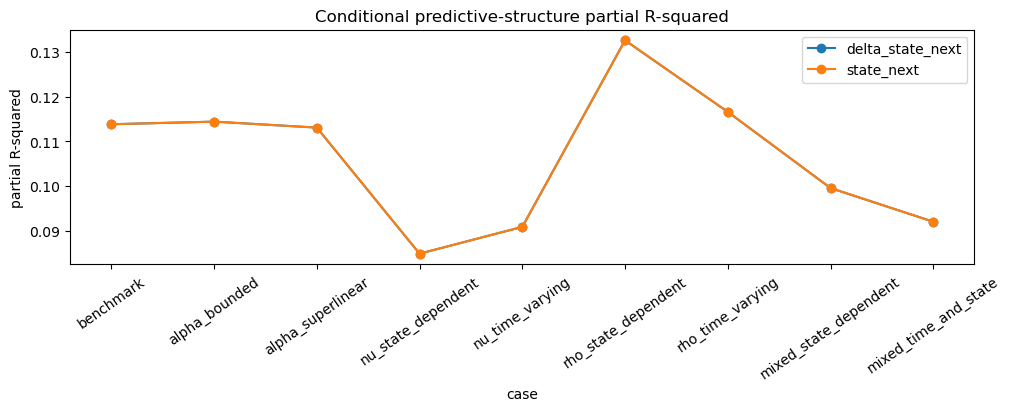

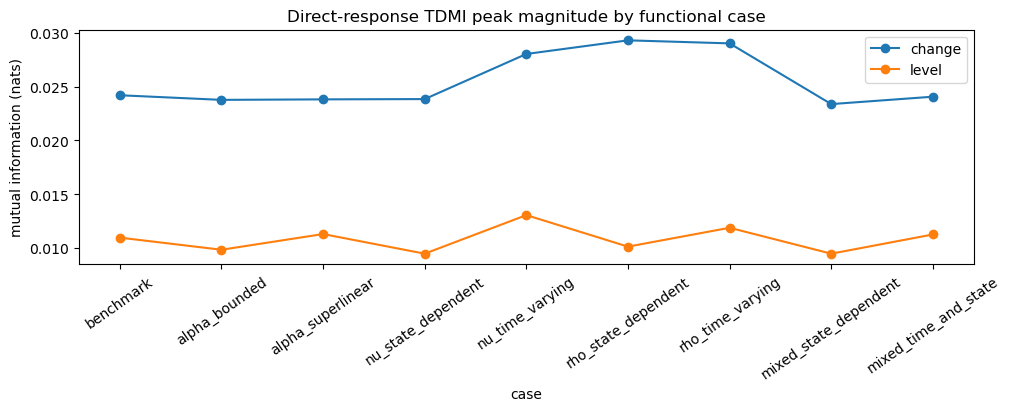

In [19]:
historical_gc_rows = []
conditional_structure_rows = []
tdmi_rows = []
for case_name, result in case_results.items():
    gc_table = result['causality']['gc'].copy()
    gc_table.insert(0, 'case_name', case_name)
    historical_gc_rows.append(gc_table[[
        'case_name', 'target', 'direction', 'lag_order', 'F_statistic', 'p_value',
        'partial_R_squared', 'sample_size', 'significant_5pct',
    ]])

    structure_table = result['causality']['conditional_structure'].copy()
    structure_table.insert(0, 'case_name', case_name)
    available_structure_columns = [
        column for column in [
            'case_name', 'target', 'direction', 'F_statistic', 'p_value',
            'partial_r_squared', 'nobs',
        ] if column in structure_table.columns
    ]
    conditional_structure_rows.append(structure_table[available_structure_columns])

    tdmi_table = result['causality']['tdmi_summary'].copy()
    tdmi_table.insert(0, 'case_name', case_name)
    tdmi_rows.append(tdmi_table[[
        'case_name', 'target', 'direct_response_peak', 'direct_response_lag',
        'first_cycle_peak', 'first_cycle_lag', 'global_peak', 'global_peak_lag',
    ]])

historical_gc_table = pd.concat(historical_gc_rows, ignore_index=True)
conditional_predictive_structure_table = pd.concat(conditional_structure_rows, ignore_index=True)
tdmi_functional_table = pd.concat(tdmi_rows, ignore_index=True)

assert len(historical_gc_table) == 2 * len(case_results)
assert len(conditional_predictive_structure_table) == 2 * len(case_results)
assert len(tdmi_functional_table) == 2 * len(case_results)
assert set(historical_gc_table['target']) == {'powered-state level', 'powered-state change'}
assert set(conditional_predictive_structure_table['target']) == {'state_next', 'delta_state_next'}
assert set(tdmi_functional_table['target']) == {'level', 'change'}
assert historical_gc_table['p_value'].between(0, 1).all()
assert conditional_predictive_structure_table['p_value'].between(0, 1).all()

print('Historical Granger causality')
display(historical_gc_table.style.format({'p_value': '{:.3e}', 'F_statistic': '{:.4f}', 'partial_R_squared': '{:.6f}'}))
print('Conditional predictive structure')
display(conditional_predictive_structure_table.style.format({'p_value': '{:.3e}', 'F_statistic': '{:.4f}', 'partial_r_squared': '{:.6f}'}))
print('Time-delayed mutual information summaries')
display(tdmi_functional_table.style.format({'direct_response_peak': '{:.6f}', 'first_cycle_peak': '{:.6f}', 'global_peak': '{:.6f}'}))

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
for target, subset in historical_gc_table.groupby('target'):
    axis.plot(subset['case_name'], subset['partial_R_squared'], marker='o', label=target)
axis.set(title='Historical GC partial R-squared by functional case', xlabel='case', ylabel='partial R-squared')
axis.tick_params(axis='x', rotation=35)
axis.legend()
plt.show()

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
for target, subset in conditional_predictive_structure_table.groupby('target'):
    axis.plot(subset['case_name'], subset['partial_r_squared'], marker='o', label=target)
axis.set(title='Conditional predictive-structure partial R-squared', xlabel='case', ylabel='partial R-squared')
axis.tick_params(axis='x', rotation=35)
axis.legend()
plt.show()

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
for target, subset in tdmi_functional_table.groupby('target'):
    axis.plot(subset['case_name'], subset['direct_response_peak'], marker='o', label=target)
axis.set(title='Direct-response TDMI peak magnitude by functional case', xlabel='case', ylabel='mutual information (nats)')
axis.tick_params(axis='x', rotation=35)
axis.legend()
plt.show()

## 9. Compact forecasting and profile comparison

The simulator performs no positivity clipping: it raises an error if an invalid path occurs. The table therefore reports the measured count of invalid states, rather than a hard-coded clipping count. Causality and information diagnostics are reported separately above; RMSE and interval-score details are kept in the second compact table.

Raw errors share the benchmark parameter scale and common shocks, but alternative dynamics can still alter the realised state distribution.

In [20]:
def _summary_row(case, result):
    summary = summarise_case(result).to_dict()
    states = result['simulation']['states']['x']
    primary = {
        'case_name': case['case_name'],
        'altered_functionals': case['description'],
        'execution_succeeded': True,
        'state_mean': float(states.mean()),
        'state_std': float(states.std(ddof=0)),
        'state_min': float(states.min()),
        'state_max': float(states.max()),
        'invalid_state_count': int((~np.isfinite(states) | (states <= 0)).sum()),
        'estimated_event_amplitude': summary['A_hat'],
        'estimated_event_decay': summary['lambda_hat'],
        'unaware_active_MAE': summary['active_sigma_unaware_MAE'],
        'parametric_active_MAE': summary['active_sigma_parametric_MAE'],
        'nonparametric_active_MAE': summary['active_sigma_nonparametric_MAE'],
        'parametric_active_MAE_gain_pct': summary['active_sigma_parametric_MAE_gain_pct'],
        'nonparametric_active_MAE_gain_pct': summary['active_sigma_nonparametric_MAE_gain_pct'],
        'parametric_active_95_coverage': summary['active_95_state_parametric_coverage'],
        'nonparametric_active_95_coverage': summary['active_95_state_nonparametric_coverage'],
    }
    detail = {
        'case_name': case['case_name'],
        'unaware_active_RMSE': summary['active_sigma_unaware_RMSE'],
        'parametric_active_RMSE': summary['active_sigma_parametric_RMSE'],
        'nonparametric_active_RMSE': summary['active_sigma_nonparametric_RMSE'],
        'parametric_active_RMSE_gain_pct': summary['active_sigma_parametric_RMSE_gain_pct'],
        'nonparametric_active_RMSE_gain_pct': summary['active_sigma_nonparametric_RMSE_gain_pct'],
        'parametric_active_95_interval_score': summary['active_95_state_parametric_interval_score'],
        'nonparametric_active_95_interval_score': summary['active_95_state_nonparametric_interval_score'],
        'event_free_parametric_MAE': _summary_value(result['evaluation']['accuracy'], {'evaluation_space':'sigma','subset':'event_free','model':'parametric'}, 'MAE'),
        'all_parametric_MAE': _summary_value(result['evaluation']['accuracy'], {'evaluation_space':'sigma','subset':'all','model':'parametric'}, 'MAE'),
    }
    return primary, detail

primary_rows, detail_rows = zip(*[_summary_row(case, case_results[case['case_name']]) for case in case_registry])
primary_comparison = pd.DataFrame(primary_rows)
rmse_interval_detail = pd.DataFrame(detail_rows)
display(primary_comparison)
display(rmse_interval_detail)

,case_name,altered_functionals,execution_succeeded,state_mean,state_std,state_min,state_max,invalid_state_count,estimated_event_amplitude,estimated_event_decay,unaware_active_MAE,parametric_active_MAE,nonparametric_active_MAE,parametric_active_MAE_gain_pct,nonparametric_active_MAE_gain_pct,parametric_active_95_coverage,nonparametric_active_95_coverage
0,benchmark,frozen benchmark functions,True,0.232872,0.018073,0.194100,0.263888,0,0.008406,36.086499,0.001015,0.000742,0.000725,26.858510,28.563767,0.945055,0.934066
1,alpha_bounded,bounded nonlinear alpha,True,0.235164,0.020494,0.194099,0.273240,0,0.008410,36.192508,0.001045,0.000750,0.000735,28.292476,29.741421,0.945055,0.934066
2,alpha_superlinear,superlinear alpha,True,0.230438,0.015726,0.194100,0.255515,0,0.008400,35.963937,0.000989,0.000737,0.000719,25.487914,27.332648,0.945055,0.934066
3,nu_state_dependent,state-dependent nu,True,0.231754,0.017979,0.194179,0.264861,0,0.008264,37.657083,0.001206,0.000967,0.000950,19.795546,21.265583,0.912088,0.901099
4,nu_time_varying,time-varying nu,True,0.232500,0.017627,0.193714,0.261817,0,0.007923,32.879301,0.000937,0.000654,0.000659,30.207097,29.667306,1.000000,1.000000
5,rho_state_dependent,state-dependent rho,True,0.232889,0.017624,0.194056,0.262656,0,0.008459,36.137457,0.000916,0.000590,0.000586,35.585164,35.980382,1.000000,0.978022
6,rho_time_varying,time-varying rho,True,0.231864,0.017048,0.193897,0.261941,0,0.008945,35.710824,0.000964,0.000671,0.000666,30.349769,30.867369,1.000000,1.000000
7,mixed_state_dependent,"bounded alpha, state nu, state rho",True,0.233754,0.019357,0.194137,0.271261,0,0.008366,38.232420,0.001086,0.000782,0.000781,27.988355,28.089286,0.945055,0.945055
8,mixed_time_and_state,"superlinear alpha, time nu, time rho",True,0.230141,0.014936,0.193480,0.253126,0,0.008550,33.873120,0.000854,0.000531,0.000549,37.846084,35.752655,1.000000,1.000000


,case_name,unaware_active_RMSE,parametric_active_RMSE,nonparametric_active_RMSE,parametric_active_RMSE_gain_pct,nonparametric_active_RMSE_gain_pct,parametric_active_95_interval_score,nonparametric_active_95_interval_score,event_free_parametric_MAE,all_parametric_MAE
0,benchmark,0.001228,0.000902,0.000916,26.551854,25.358069,0.004072,0.004239,0.000633,0.000701
1,alpha_bounded,0.001260,0.000913,0.000929,27.534926,26.295702,0.004170,0.004323,0.000638,0.000707
2,alpha_superlinear,0.001199,0.000893,0.000907,25.523242,24.374243,0.003987,0.004167,0.000632,0.000697
3,nu_state_dependent,0.001471,0.001184,0.001199,19.513471,18.489302,0.005556,0.005856,0.000822,0.000912
4,nu_time_varying,0.001124,0.000786,0.000814,30.037548,27.523783,0.003997,0.003996,0.000551,0.000615
5,rho_state_dependent,0.001088,0.000728,0.000746,33.075980,31.459599,0.003322,0.003493,0.000505,0.000558
6,rho_time_varying,0.001150,0.000807,0.000820,29.770110,28.687040,0.003725,0.003725,0.000575,0.000635
7,mixed_state_dependent,0.001299,0.000968,0.000988,25.506762,23.925217,0.004268,0.004467,0.000667,0.000738
8,mixed_time_and_state,0.001013,0.000668,0.000692,34.110089,31.677440,0.004159,0.004159,0.000441,0.000497


## 10. Diagnostic figures

The path figures retain a common powered-state y-axis across panels to support honest paired comparisons.

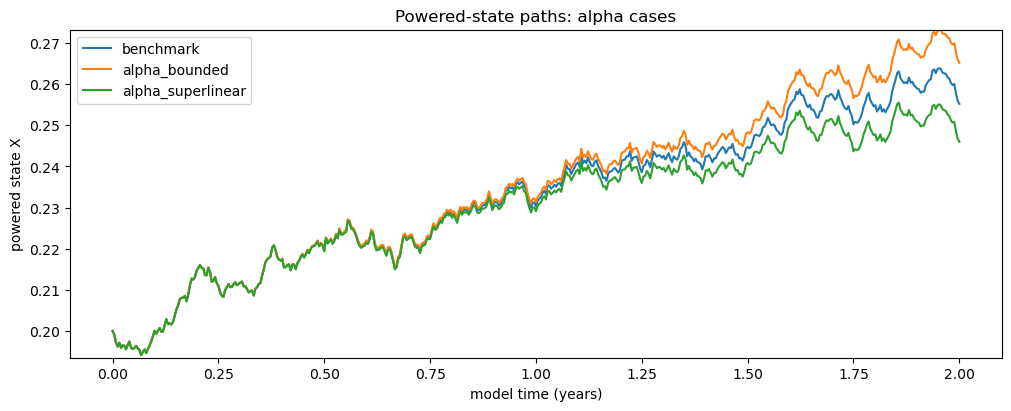

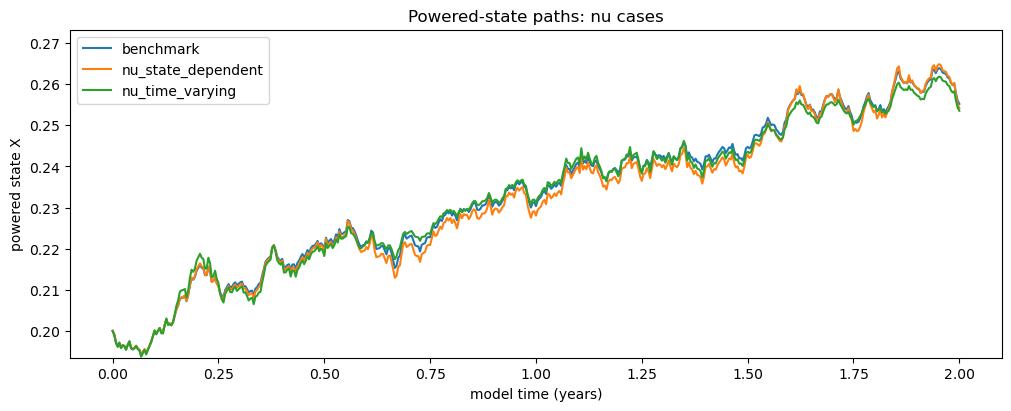

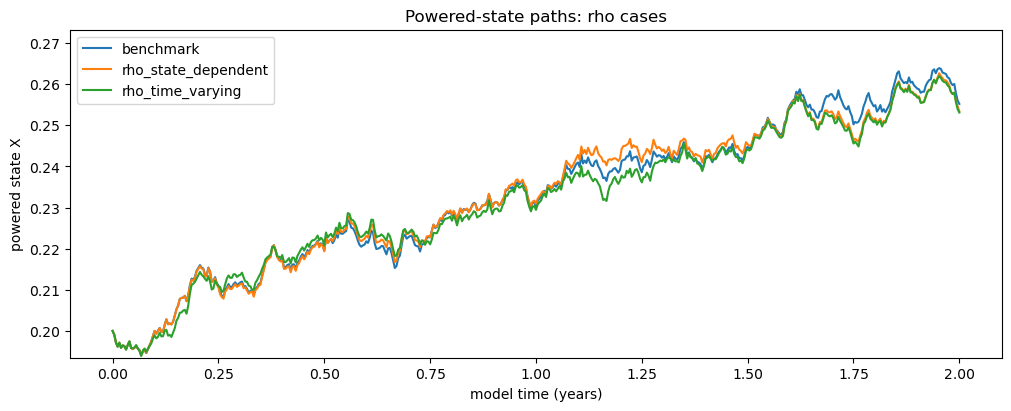

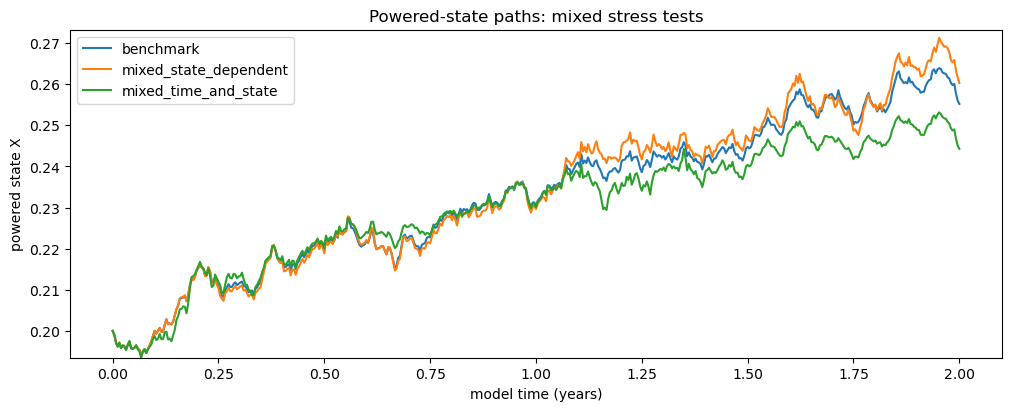

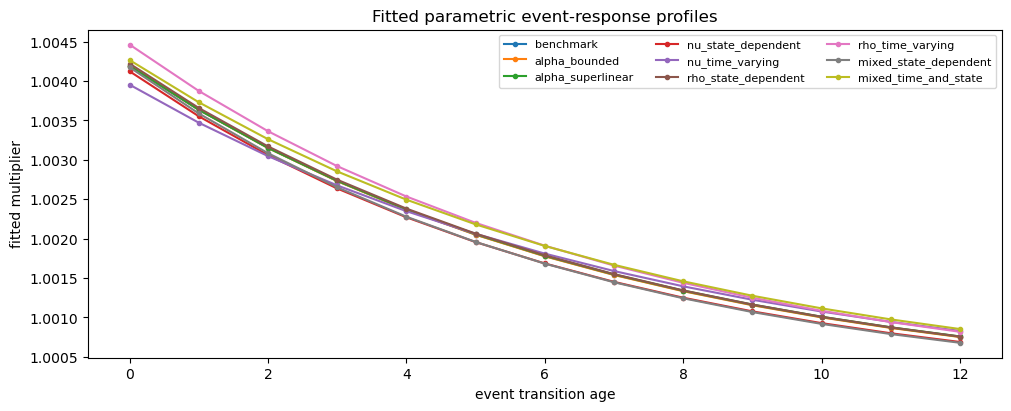

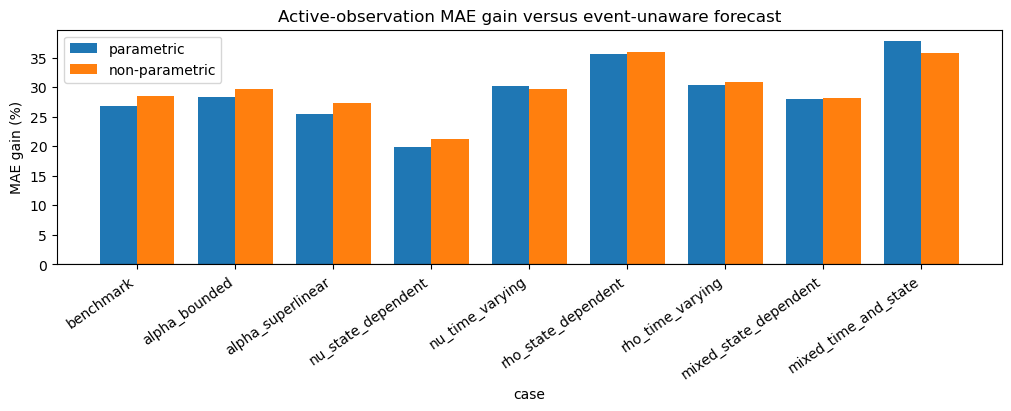

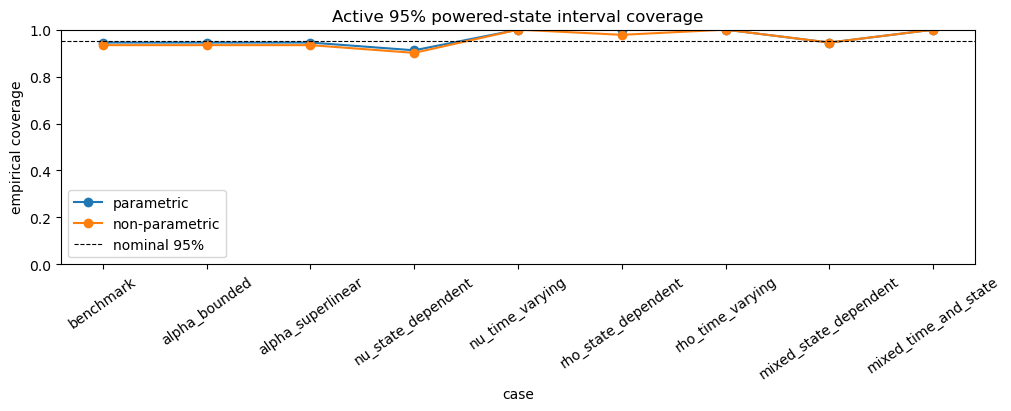

In [21]:
all_state_values = np.concatenate([result['simulation']['states']['x'].to_numpy() for result in case_results.values()])
state_ylim = (float(all_state_values.min()), float(all_state_values.max()))

def plot_state_paths(case_names, title):
    fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
    for name in case_names:
        states = case_results[name]['simulation']['states']
        axis.plot(states['t'], states['x'], label=name)
    axis.set(title=title, xlabel='model time (years)', ylabel='powered state X')
    axis.set_ylim(*state_ylim)
    axis.legend()
    plt.show()

plot_state_paths(['benchmark','alpha_bounded','alpha_superlinear'], 'Powered-state paths: alpha cases')
plot_state_paths(['benchmark','nu_state_dependent','nu_time_varying'], 'Powered-state paths: nu cases')
plot_state_paths(['benchmark','rho_state_dependent','rho_time_varying'], 'Powered-state paths: rho cases')
plot_state_paths(['benchmark','mixed_state_dependent','mixed_time_and_state'], 'Powered-state paths: mixed stress tests')

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
for name, result in case_results.items():
    ages = np.asarray(result['timing']['event_transition_ages'])
    profile = result['profiles']['parametric_multiplier'](ages)
    axis.plot(ages, profile, marker='o', markersize=3, label=name)
axis.set(title='Fitted parametric event-response profiles', xlabel='event transition age', ylabel='fitted multiplier')
axis.legend(ncol=3, fontsize=8)
plt.show()

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
positions = np.arange(len(primary_comparison))
width = 0.38
axis.bar(positions-width/2, primary_comparison['parametric_active_MAE_gain_pct'], width, label='parametric')
axis.bar(positions+width/2, primary_comparison['nonparametric_active_MAE_gain_pct'], width, label='non-parametric')
axis.axhline(0, color='black', linewidth=0.8)
axis.set(title='Active-observation MAE gain versus event-unaware forecast', xlabel='case', ylabel='MAE gain (%)')
axis.set_xticks(positions, primary_comparison['case_name'], rotation=35, ha='right')
axis.legend(); plt.show()

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
axis.plot(primary_comparison['case_name'], primary_comparison['parametric_active_95_coverage'], marker='o', label='parametric')
axis.plot(primary_comparison['case_name'], primary_comparison['nonparametric_active_95_coverage'], marker='o', label='non-parametric')
axis.axhline(0.95, color='black', linestyle='--', linewidth=0.8, label='nominal 95%')
axis.set(title='Active 95% powered-state interval coverage', xlabel='case', ylabel='empirical coverage', ylim=(0,1))
axis.tick_params(axis='x', rotation=35)
axis.legend(); plt.show()

## 11. Mechanical validation summary

These checks use the actual returned workflow objects, common innovations, and case registry. They do not infer robustness from source text or manually assigned flags.

In [22]:
case_validation_checks = {
    'Notebook 06 loaded with self-tests disabled': RUN_HELPER_SELF_TESTS is False,
    'exactly nine registry cases': len(case_registry) == 9,
    'benchmark has no function overrides': case_registry[0]['functions'] == {},
    'isolated cases use partial overrides only': all(len(case['functions']) == 1 for case in case_registry[1:7]),
    'mixed cases use three overrides': all(len(case['functions']) == 3 for case in case_registry[7:]),
    'common epsilon innovations reused': all(np.array_equal(result['simulation']['transitions']['epsilon'], benchmark_result['simulation']['transitions']['epsilon']) for result in case_results.values()),
    'common eta innovations reused': all(np.array_equal(result['simulation']['transitions']['eta'], benchmark_result['simulation']['transitions']['eta']) for result in case_results.values()),
    'event timing unchanged': all(np.array_equal(result['simulation']['config']['event_times'], benchmark_result['simulation']['config']['event_times']) for result in case_results.values()),
    'all cases retain n equals one': all(result['config']['model']['n'] == 1 for result in case_results.values()),
    'all simulated states finite and positive': all(result['simulation']['states'][['S','sigma','x']].gt(0).all().all() for result in case_results.values()),
    'simulator reports no invalid state paths': primary_comparison['invalid_state_count'].eq(0).all(),
    'all cases use frozen estimator inputs': all({'state_i','epsilon_proxy_i'} == set(result['baseline']['feature_names']) for result in case_results.values()),
    'truth excluded from all fitted robustness cases': all(result['truth'] is None for result in case_results.values()),
    'benchmark reproduction is deterministic': np.isclose(benchmark_summary['A_hat'], repeat_summary['A_hat']) and np.isclose(benchmark_summary['active_sigma_parametric_MAE'], repeat_summary['active_sigma_parametric_MAE']),
    'all case summaries contain primary fields': primary_comparison[['estimated_event_amplitude','parametric_active_MAE','parametric_active_95_coverage']].notna().all().all(),
    'functional diagnostics passed': all(np.isfinite(values).all() for values in all_function_values) and (nu_state_values > 0).all() and ((rho_state_values > -1) & (rho_state_values < 1)).all(),
    'historical GC table contains every case and target': len(historical_gc_table) == 18 and historical_gc_table[['case_name','target']].drop_duplicates().shape[0] == 18,
    'conditional predictive-structure table contains every case and target': len(conditional_predictive_structure_table) == 18 and conditional_predictive_structure_table[['case_name','target']].drop_duplicates().shape[0] == 18,
    'TDMI table contains every case and target': len(tdmi_functional_table) == 18 and tdmi_functional_table[['case_name','target']].drop_duplicates().shape[0] == 18,
    'causality diagnostics use finite statistics': np.isfinite(historical_gc_table[['F_statistic','partial_R_squared']]).all().all() and np.isfinite(conditional_predictive_structure_table[['F_statistic','partial_r_squared']]).all().all() and np.isfinite(tdmi_functional_table[['direct_response_peak','global_peak']]).all().all(),
}
assert all(case_validation_checks.values())
case_validation_summary = pd.DataFrame({'check':case_validation_checks.keys(),'passed':case_validation_checks.values()})
display(case_validation_summary)
print(f'Notebook 07 validation summary: {len(case_validation_summary)} checks passed.')

,check,passed
0,Notebook 06 loaded with self-tests disabled,True
1,exactly nine registry cases,True
2,benchmark has no function overrides,True
3,isolated cases use partial overrides only,True
4,mixed cases use three overrides,True
5,common epsilon innovations reused,True
6,common eta innovations reused,True
7,event timing unchanged,True
8,all cases retain n equals one,True
9,all simulated states finite and positive,True


Notebook 07 validation summary: 20 checks passed.


## 12. Interpretation from this common-shock experiment

The following statements are generated from the current single-seed result. They are descriptive robustness evidence, not structural-causality claims. Historical GC and TDMI are dependence summaries; the conditional predictive-structure test remains distinct from Granger causality.

In [23]:
best_parametric_case = primary_comparison.loc[primary_comparison['parametric_active_MAE_gain_pct'].idxmax()]
worst_parametric_case = primary_comparison.loc[primary_comparison['parametric_active_MAE_gain_pct'].idxmin()]
coverage_distance = (primary_comparison['parametric_active_95_coverage'] - 0.95).abs()
least_calibrated_case = primary_comparison.loc[coverage_distance.idxmax()]
state_range_case = primary_comparison.loc[(primary_comparison['state_max'] - primary_comparison['state_min']).idxmax()]

gc_level_by_case = historical_gc_table.loc[historical_gc_table['target'].eq('powered-state level')].set_index('case_name')
gc_change_by_case = historical_gc_table.loc[historical_gc_table['target'].eq('powered-state change')].set_index('case_name')
structure_by_case = conditional_predictive_structure_table.loc[conditional_predictive_structure_table['target'].eq('state_next')].set_index('case_name')
tdmi_level_by_case = tdmi_functional_table.loc[tdmi_functional_table['target'].eq('level')].set_index('case_name')
tdmi_change_by_case = tdmi_functional_table.loc[tdmi_functional_table['target'].eq('change')].set_index('case_name')

strongest_gc_case = gc_level_by_case['partial_R_squared'].idxmax()
weakest_gc_case = gc_level_by_case['partial_R_squared'].idxmin()
strongest_structure_case = structure_by_case['partial_r_squared'].idxmax()
level_lag_values = sorted(tdmi_level_by_case['direct_response_lag'].unique().tolist())
change_lag_values = sorted(tdmi_change_by_case['direct_response_lag'].unique().tolist())
all_gc_significant = bool(historical_gc_table['significant_5pct'].all())
lag_disagreement_cases = sorted(set(tdmi_level_by_case.index[tdmi_level_by_case['direct_response_lag'] != tdmi_change_by_case['direct_response_lag']]))

interpretation = f"""
### Findings from the single common-shock run

- The largest powered-state range occurs in **{state_range_case['case_name']}**. This is a changed simulated path under the common shocks, not an estimator redesign.
- Historical GC is significant at 5% for every reported target/case combination: **{all_gc_significant}**. For powered-state level, partial $R^2$ is strongest in **{strongest_gc_case}** and weakest in **{weakest_gc_case}**. The largest state-next conditional predictive-structure partial $R^2$ occurs in **{strongest_structure_case}**; this conditional test is not Granger causality.
- Direct-response TDMI level lags are {level_lag_values}; change lags are {change_lag_values}. Cases with differing level and change direct lags are {lag_disagreement_cases or 'none'}. TDMI magnitudes and lags therefore need not give the same message as linear GC under changed functionals.
- Parametric event-aware active MAE gain is largest in **{best_parametric_case['case_name']}** ({best_parametric_case['parametric_active_MAE_gain_pct']:.2f}%) and weakest in **{worst_parametric_case['case_name']}** ({worst_parametric_case['parametric_active_MAE_gain_pct']:.2f}%). Event-profile recovery and forecasting can move differently from dependence diagnostics when baseline dynamics are misspecified.
- The parametric 95% interval is furthest from nominal coverage in **{least_calibrated_case['case_name']}** ({least_calibrated_case['parametric_active_95_coverage']:.3f}). Good point forecasts would not by themselves establish calibrated intervals.
- Nonlinear alpha changes the conditional pre-event state; state-dependent nu changes both observed price-shock loading and latent innovation variance; state-dependent rho changes the share of volatility shock revealed through price movement. Time-varying nu or rho can therefore misspecify frozen constant-coefficient or constant-residual-variance components.

Historical GC is a linear predictive test. Under nonlinear data-generating dynamics, weaker GC evidence may reflect functional misspecification rather than absence of event dependence. TDMI can capture nonlinear dependence but is not by itself proof of structural causality. Estimated event parameters under misspecified baseline dynamics are not structural parameters, and the mixed cases are stress tests rather than isolated attribution experiments.
"""
display(Markdown(interpretation))


### Findings from the single common-shock run

- The largest powered-state range occurs in **alpha_bounded**. This is a changed simulated path under the common shocks, not an estimator redesign.
- Historical GC is significant at 5% for every reported target/case combination: **True**. For powered-state level, partial $R^2$ is strongest in **rho_time_varying** and weakest in **mixed_state_dependent**. The largest state-next conditional predictive-structure partial $R^2$ occurs in **rho_state_dependent**; this conditional test is not Granger causality.
- Direct-response TDMI level lags are [6, 7, 8, 9]; change lags are [1, 3, 9]. Cases with differing level and change direct lags are ['alpha_bounded', 'alpha_superlinear', 'benchmark', 'mixed_state_dependent', 'mixed_time_and_state', 'nu_state_dependent', 'nu_time_varying', 'rho_state_dependent', 'rho_time_varying']. TDMI magnitudes and lags therefore need not give the same message as linear GC under changed functionals.
- Parametric event-aware active MAE gain is largest in **mixed_time_and_state** (37.85%) and weakest in **nu_state_dependent** (19.80%). Event-profile recovery and forecasting can move differently from dependence diagnostics when baseline dynamics are misspecified.
- The parametric 95% interval is furthest from nominal coverage in **nu_time_varying** (1.000). Good point forecasts would not by themselves establish calibrated intervals.
- Nonlinear alpha changes the conditional pre-event state; state-dependent nu changes both observed price-shock loading and latent innovation variance; state-dependent rho changes the share of volatility shock revealed through price movement. Time-varying nu or rho can therefore misspecify frozen constant-coefficient or constant-residual-variance components.

Historical GC is a linear predictive test. Under nonlinear data-generating dynamics, weaker GC evidence may reflect functional misspecification rather than absence of event dependence. TDMI can capture nonlinear dependence but is not by itself proof of structural causality. Estimated event parameters under misspecified baseline dynamics are not structural parameters, and the mixed cases are stress tests rather than isolated attribution experiments.


## Next controlled extension

The natural next step is paired Monte Carlo replication across common seeds, followed only later by an observable-feature augmentation ablation for cases where the frozen estimator performs poorly.